In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
%%capture
!pip install accelerate transformers einops datasets peft bitsandbytes

In [ ]:
%%capture
!pip install flash_attn

In [ ]:
import torch
from datasets import load_dataset, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
import os

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-1_5", trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-1_5",
    device_map={"":0},
    trust_remote_code=True,
    quantization_config=bnb_config
)

config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

In [ ]:
print(model)

PhiForCausalLM(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2048)
    (layers): ModuleList(
      (0-23): 24 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (v_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (dense): Linear4bit(in_features=2048, out_features=2048, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear4bit(in_features=2048, out_features=8192, bias=True)
          (fc2): Linear4bit(in_features=8192, out_features=2048, bias=True)
        )
        (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_layernorm): La

In [ ]:
config = LoraConfig(
    r=8,
    lora_alpha=24,
    target_modules=["dense", "fc2","q_proj","k_proj","v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 5,111,808 || all params: 1,423,382,528 || trainable%: 0.3591


In [ ]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split
filename='/content/filtered_data.csv'
df = pd.read_csv(filename,
                 names=["question", "answer"],
                 encoding="utf-8", encoding_errors="replace")


train, test = train_test_split(df, test_size=0.2,random_state = 42)
train_data = Dataset.from_pandas(train)
test_dataframe = Dataset.from_pandas(test)


In [ ]:
test_data=test_dataframe[:len(test_dataframe)//2]
eval_data=test_dataframe[len(test_dataframe)//2:]
print(eval_data['question'][0])
print(eval_data['answer'][0])

What are the things moving under the earth's mantle that move the crust?
plates What portion of Earth makes up the “plates” in plate tectonics? Again, the answer came about in part due to war. In this case, the Cold War. The scientists set up seismometer networks during the 1950s and early 1960s. The purpose was to see if other nations were testing atomic bombs. Since seismometers measure ground shaking, they also recorded earthquakes.


In [ ]:
test_data= Dataset.from_pandas(pd.DataFrame(test_data))
eval_data= Dataset.from_pandas(pd.DataFrame(eval_data))
print(eval_data)

Dataset({
    features: ['question', 'answer', '__index_level_0__'],
    num_rows: 1160
})


In [ ]:
def generate_prompt(data_point):
    return f"""
            {data_point["question"]}.
            Answer as briefly as possible: {data_point["answer"]}
            """.strip()


def generate_and_tokenize_prompt(data_point):
    full_prompt = generate_prompt(data_point)
    tokenized_full_prompt = tokenizer(full_prompt, padding=True, truncation=True)
    return tokenized_full_prompt

train_data = train_data.shuffle().map(generate_and_tokenize_prompt)
eval_data= eval_data.shuffle().map(generate_and_tokenize_prompt)
test_data= test_data.shuffle().map(generate_and_tokenize_prompt)

Map:   0%|          | 0/9273 [00:00<?, ? examples/s]

Map:   0%|          | 0/1160 [00:00<?, ? examples/s]

Map:   0%|          | 0/1159 [00:00<?, ? examples/s]

In [ ]:
training_arguments = TrainingArguments(
        output_dir="/content/model",
        per_device_train_batch_size=4,
        gradient_accumulation_steps=1,
        learning_rate=2e-5,
        lr_scheduler_type="cosine",
        save_strategy="epoch",
        logging_steps=100,
        max_steps=2500,
        num_train_epochs=1,
        push_to_hub=True,
        save_steps=500

    )


In [ ]:

trainer = Trainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=eval_data,
    args=training_arguments,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer.train()

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: roysayantan-blr99 (roysayantan-blr99-iiit-naya-raipur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
100,2.511000
200,1.995500
300,1.877900
400,1.879200
500,1.842200
600,1.880600
700,1.844300
800,1.875700
900,1.857100
1000,1.877500


TrainOutput(global_step=2500, training_loss=1.8789870666503907, metrics={'train_runtime': 1291.2142, 'train_samples_per_second': 7.745, 'train_steps_per_second': 1.936, 'total_flos': 1.6244920657072128e+16, 'train_loss': 1.8789870666503907, 'epoch': 1.0780508840017249})

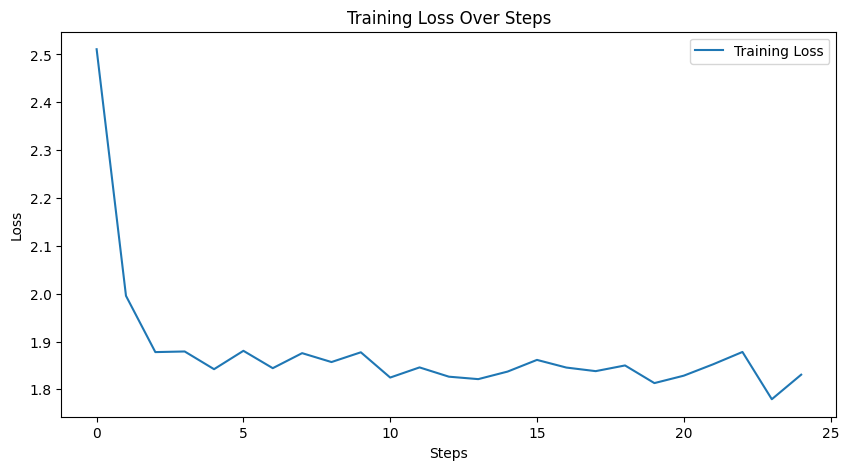

In [ ]:
import matplotlib.pyplot as plt

# Assuming trainer has stored logs in a way that you can access them
logs = trainer.state.log_history  # This will contain all logged metrics

# Extracting loss values
loss_values = [log['loss'] for log in logs if 'loss' in log]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(loss_values, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Steps')
plt.legend()
plt.show()


# Saving the model on HuggingFace

In [ ]:
model.push_to_hub('roydev99/phi1.5_3')

adapter_model.safetensors:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/roydev99/phi1.5_3/commit/06255d8d68f294d3548e3f6ed71c5f4098e5342e', commit_message='Upload model', commit_description='', oid='06255d8d68f294d3548e3f6ed71c5f4098e5342e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/roydev99/phi1.5_3', endpoint='https://huggingface.co', repo_type='model', repo_id='roydev99/phi1.5_3'), pr_revision=None, pr_num=None)